# 2024 HLT diphoton trigger efficiency -- build CSV + efficiency plots

**Purpose:** Parse the tag-and-probe fit outputs (`egammaEffi.txt`, produced upstream by the
TnP fitter for each eta/R9/pt bin) for the 2024 HLT legs and consolidate them into one
long-format CSV, then plot efficiency vs probe pt per R9 category -- the same deliverable
that `HLT_2023_lowmass_final_csv_jsons/diagnostics/2026-06-25_build_eff_csv_from_txt.py` and
`2026-06-25_plot_fullpath_efficiency.py` produced for 2023, now as one notebook so each step
is visible and re-runnable.

**The four variants** -- two axes crossed:
- eta-R9 reweighting derived **without** (`noPresel`) vs **with** (`withPresel`) the photon preselection;
- trigger selection: track-isolation `SS` (normal) vs `fullPath` (the full HLT path requirement,
  `probe_passFullPath == 1`, added on top).

Giving: `etaR9rw_noPresel`, `etaR9rw_withPresel`, `etaR9rw_noPresel_fullPath`,
`etaR9rw_withPresel_fullPath`. The raw fitter output directories
(`HLT_2024_{noPresel,withPresel}[_fullPath]_SS`) are relabelled to these `etaR9rw_*` names in the
CSV and plot filenames so the reweighting + fullPath meaning is explicit in every downstream artifact.

**Inputs:**
- `results/HLT_2024_noPresel_SS/passingHLT_*_2024/egammaEffi.txt`
- `results/HLT_2024_withPresel_SS/passingHLT_*_2024/egammaEffi.txt`
- `results/HLT_2024_noPresel_fullPath_SS/passingHLT_*_2024/egammaEffi.txt`
- `results/HLT_2024_withPresel_fullPath_SS/passingHLT_*_2024/egammaEffi.txt`

**Outputs:**
- `outputs/efficiencies_from_txt.csv` -- long format, one row per (era, leg, region, R9 bin, pt
  bin, fit variant); `era` column holds the `etaR9rw_*` label.
- `plots/efficiency-data-passing_{seeded,unseeded}_2024_etaR9rw_{noPresel,withPresel}.{png,pdf}` --
  one panel per variant x leg, R9 categories overlaid, saved to disk AND rendered inline below.

**Method summary:**
- Only `bwDscbCms` and `bwDscbExp` fit variants are populated in the source `egammaEffi.txt`
  files (the other 6 variant columns are placeholder `-1`); the CSV keeps both, the plots use
  the nominal `bwDscbCms` fit only, matching the 2023 convention.
- Bin directories are matched by folder name pattern `passingHLT_(seed|unseed)_(EB|EE)_(R9...)_2024`.
- Efficiency error bars plotted are the asymmetric fit errors (`elo`, `ehi`) from the nominal fit,
  not a combined systematic -- same as the 2023 `plot_fullpath_efficiency.py` script (which did not
  add a bkg-variant systematic either).

**Completeness (this run):** all **four** variants are complete -- 5 R9/eta categories x both legs
(seed + unseed) fit successfully for each, 80 (era, leg, region, R9 bin) combinations total.
Section 5 asserts no dummy (0.5) values remain.

**Assumptions:** the lumi value carried in the fitter settings files (109.08 fb$^{-1}$) is flagged
`PLACEHOLDER` there, so it is deliberately NOT written onto the plots as if it were a confirmed
integrated luminosity.


## 1. Imports
Standard scientific-python stack plus `pathlib`/`re`/`csv` for the file walk.

In [1]:
import csv          # write the consolidated long-format CSV
import re            # match bin-directory names to (leg, region, R9 bin)
from pathlib import Path

import pandas as pd            # tabular view + easy groupby for validation/plots
import matplotlib.pyplot as plt
%matplotlib inline


## 2. Config

Paths and constants live here so re-running on a different results directory only means
editing this one cell. `ERA_LABEL` is the whitelist that (a) restricts the build to the two
normal `SS` variants -- anything else under `results/` (e.g. the incomplete `*_fullPath_SS`
directories) is skipped -- and (b) maps each raw fitter directory name to the explicit
`etaR9rw_*` label used everywhere downstream. `VARIANTS` lists the 8 fit-variant column groups
that `egammaEffi.txt` always has (even if only some are filled with real numbers).


In [2]:
ROOT = Path("/home/santanu/Desktop/HLT_2024_lowmass_final")
RESULTS_DIR = ROOT / "results"
OUT_CSV = ROOT / "outputs" / "efficiencies_from_txt.csv"
PLOTS_DIR = ROOT / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# raw fitter results dir -> explicit label (also the whitelist: only these eras are built).
# noPresel/withPresel = eta-R9 reweighting derived WITHOUT / WITH the photon preselection.
# _fullPath = the full HLT path requirement (probe_passFullPath==1) added on top of the SS selection.
ERA_LABEL = {
    "HLT_2024_noPresel_SS":            "etaR9rw_noPresel",
    "HLT_2024_withPresel_SS":          "etaR9rw_withPresel",
    "HLT_2024_noPresel_fullPath_SS":   "etaR9rw_noPresel_fullPath",
    "HLT_2024_withPresel_fullPath_SS": "etaR9rw_withPresel_fullPath",
}
# label -> human-readable string for the CMS-style plot header
ERA_DISPLAY = {
    "etaR9rw_noPresel":            "eta-R9 rwt, no presel",
    "etaR9rw_withPresel":          "eta-R9 rwt, with presel",
    "etaR9rw_noPresel_fullPath":   "eta-R9 rwt, no presel, fullPath",
    "etaR9rw_withPresel_fullPath": "eta-R9 rwt, with presel, fullPath",
}

# egammaEffi.txt column groups, in file order: each variant contributes (eff, err_lo, err_hi)
VARIANTS = [
    "nomFit", "nomExpFit", "altSigFit", "altBkgFit",
    "altSigAddGaus", "altBkgAddGaus", "bwDscbCms", "bwDscbExp",
]

# bin-directory name -> (leg, region, R9 bin); 2024 bin dirs carry a trailing "_2024" suffix
# that 2023's bin dirs did not have.
LEG_RE = re.compile(r"passingHLT_(seed|unseed)_(EB|EE)_(R9.+)_2024$")

print("ROOT       :", ROOT)
print("RESULTS_DIR:", RESULTS_DIR)
print("OUT_CSV    :", OUT_CSV)
print("PLOTS_DIR  :", PLOTS_DIR)
print("eras built :", list(ERA_LABEL.values()))


ROOT       : /home/santanu/Desktop/HLT_2024_lowmass_final
RESULTS_DIR: /home/santanu/Desktop/HLT_2024_lowmass_final/results
OUT_CSV    : /home/santanu/Desktop/HLT_2024_lowmass_final/outputs/efficiencies_from_txt.csv
PLOTS_DIR  : /home/santanu/Desktop/HLT_2024_lowmass_final/plots
eras built : ['etaR9rw_noPresel', 'etaR9rw_withPresel', 'etaR9rw_noPresel_fullPath', 'etaR9rw_withPresel_fullPath']


## 3. Walk `egammaEffi.txt` files and parse rows

Only the directories listed in `ERA_LABEL` are walked (so `*_fullPath_SS` is skipped). Each
contains one subdirectory per (leg, region, R9 bin); inside each, `egammaEffi.txt` has one row
per (eta, pt) bin with 4 header columns (`eta_lo, eta_hi, et_lo, et_hi`) followed by 8 variants x
3 columns (`eff, err_lo, err_hi`). A variant that wasn't fit is written as `eff = -1.00000` and
is skipped here (kept out of the CSV rather than written as a fake efficiency).


In [3]:
rows = []
skipped_dirs = []

for era_dirname, era_label in ERA_LABEL.items():
    era_dir = RESULTS_DIR / era_dirname
    if not era_dir.is_dir():
        print(f"[WARN] expected era dir missing: {era_dir}")
        continue

    for bin_dir in sorted(era_dir.iterdir()):
        m = LEG_RE.match(bin_dir.name)
        if not m:
            continue  # not a passingHLT_* bin directory
        leg, region, r9bin = m.group(1), m.group(2), m.group(3)

        txt = bin_dir / "egammaEffi.txt"
        if not txt.exists():
            skipped_dirs.append(bin_dir)
            continue

        with open(txt) as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith("###"):
                    continue  # header/comment line
                parts = line.split()
                if len(parts) < 4 + 3 * len(VARIANTS):
                    continue  # malformed/short line, skip rather than guess
                eta_lo, eta_hi, et_lo, et_hi = map(float, parts[:4])
                for i, variant in enumerate(VARIANTS):
                    eff = float(parts[4 + 3 * i])
                    elo = float(parts[5 + 3 * i])
                    ehi = float(parts[6 + 3 * i])
                    if eff < 0:  # sentinel for "this variant was not fit"
                        continue
                    rows.append({
                        "era": era_label, "leg": leg, "region": region, "R9bin": r9bin,
                        "eta_lo": eta_lo, "eta_hi": eta_hi,
                        "et_lo": et_lo, "et_hi": et_hi,
                        "variant": variant, "eff": eff,
                        "err_lo": elo, "err_hi": ehi,
                    })

print(f"parsed {len(rows)} rows")
print(f"skipped {len(skipped_dirs)} bin dir(s) with no egammaEffi.txt:")
for d in skipped_dirs:
    print(" ", d)


parsed 840 rows
skipped 0 bin dir(s) with no egammaEffi.txt:


## 4. Write the consolidated CSV

Same schema as the 2023 output (`era, leg, region, R9bin, eta_lo, eta_hi, et_lo, et_hi, variant,
eff, err_lo, err_hi`) so downstream tooling that already reads the 2023 CSV needs no changes --
the only difference is that `era` here carries the `etaR9rw_*` reweighting label.


In [4]:
df = pd.DataFrame(rows)

OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
with open(OUT_CSV, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    w.writeheader()
    w.writerows(rows)

print(f"wrote {len(df)} rows -> {OUT_CSV}")
df.head()


wrote 840 rows -> /home/santanu/Desktop/HLT_2024_lowmass_final/outputs/efficiencies_from_txt.csv


,era,leg,region,R9bin,eta_lo,eta_hi,et_lo,et_hi,variant,eff,err_lo,err_hi
0,etaR9rw_noPresel,seed,EB,R9_0p50to0p55,0.0,1.444,0.0,35.0,bwDscbCms,0.81763,0.00773,0.00398
1,etaR9rw_noPresel,seed,EB,R9_0p50to0p55,0.0,1.444,0.0,35.0,bwDscbExp,0.79882,0.00116,0.00117
2,etaR9rw_noPresel,seed,EB,R9_0p50to0p55,0.0,1.444,35.0,37.0,bwDscbCms,0.88898,0.00133,0.00133
3,etaR9rw_noPresel,seed,EB,R9_0p50to0p55,0.0,1.444,35.0,37.0,bwDscbExp,0.88886,0.00125,0.00124
4,etaR9rw_noPresel,seed,EB,R9_0p50to0p55,0.0,1.444,37.0,40.0,bwDscbCms,0.90540,0.00100,0.00100


## 5. Validate: value range, no leftover dummies, variant coverage, bin coverage

Sanity checks before trusting the CSV:
- efficiency must lie in [0, 1] (physical bound for a fit efficiency)
- **no leftover dummy `0.5000` values** -- the earlier fitter run wrote `0.5 +/- 0.001` for the
  three unseed categories that failed to converge; after the re-fit none should remain
- only `bwDscbCms`/`bwDscbExp` should be populated (matches 2023 -- the other 6 variant columns
  are placeholders in the upstream fitter output for this analysis)
- list which (era, leg, region, R9bin) combinations made it into the CSV -- expect the full
  5 categories x 2 legs for each of the 4 variants (10 combos per variant, 40 total).


In [5]:
print("eff range:", df["eff"].min(), "to", df["eff"].max())
assert df["eff"].between(0.0, 1.0).all(), "efficiency outside [0,1] -- investigate before trusting the CSV"

# leftover-dummy check: the fitter's non-convergence sentinel is exactly 0.5 +/- 0.001
dummy = df[(df["eff"] == 0.5) & (df["err_lo"] == 0.001) & (df["err_hi"] == 0.001)]
print("leftover dummy (0.5 +/- 0.001) rows:", len(dummy))
assert len(dummy) == 0, "dummy sentinel values still present -- a fit did not converge, do not publish"

print()
print("rows per fit variant:")
print(df["variant"].value_counts())

print()
combos = df[["era", "leg", "region", "R9bin"]].drop_duplicates().sort_values(
    ["era", "leg", "region", "R9bin"]
)
print(f"(era, leg, region, R9bin) combinations present: {len(combos)}")
combos


eff range: 0.69903 to 0.99992
leftover dummy (0.5 +/- 0.001) rows: 0

rows per fit variant:
variant
bwDscbCms    420
bwDscbExp    420
Name: count, dtype: int64

(era, leg, region, R9bin) combinations present: 40


,era,leg,region,R9bin
0,etaR9rw_noPresel,seed,EB,R9_0p50to0p55
18,etaR9rw_noPresel,seed,EB,R9_0p55to0p85
36,etaR9rw_noPresel,seed,EB,R9gt0p85
54,etaR9rw_noPresel,seed,EE,R9_0p90to0p93
72,etaR9rw_noPresel,seed,EE,R9gt0p93
90,etaR9rw_noPresel,unseed,EB,R9_0p50to0p55
114,etaR9rw_noPresel,unseed,EB,R9_0p55to0p85
138,etaR9rw_noPresel,unseed,EB,R9gt0p85
162,etaR9rw_noPresel,unseed,EE,R9_0p90to0p93
186,etaR9rw_noPresel,unseed,EE,R9gt0p93


## 6. Plot efficiency vs probe pt, one panel per (variant, leg)

Mirrors `HLT_2023_lowmass_final_csv_jsons/diagnostics/2026-06-25_plot_fullpath_efficiency.py`:
one panel per variant x leg, R9 categories overlaid as separate colored series, nominal
`bwDscbCms` fit only, asymmetric error bars, lowest catch-all pt bin dropped (`et_lo >= min_pt`,
`min_pt = 35 GeV` for the seed/lead leg and `21 GeV` for the unseed/sublead leg -- these are the
same thresholds 2023 used and the 2024 pt binning starts at the same catch-all edges).

Every figure is both shown inline below (so this notebook is a self-contained review record)
and saved to `plots/` as PNG + PDF, per the global notebook convention.


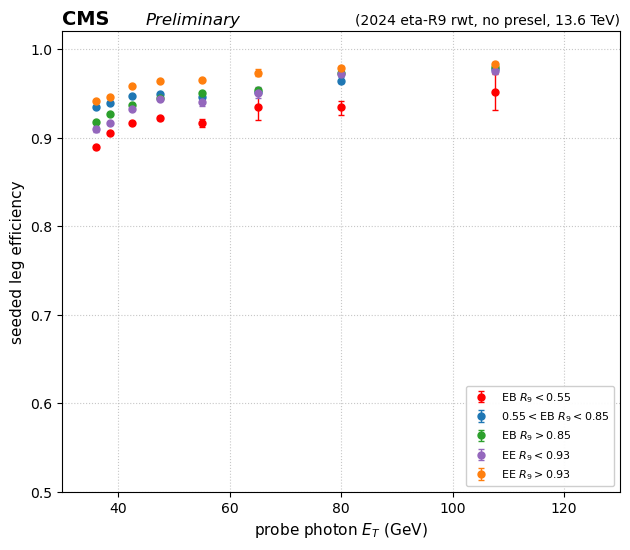

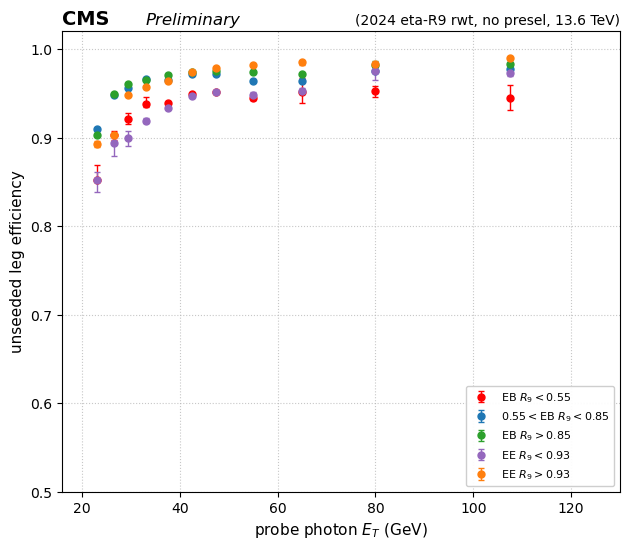

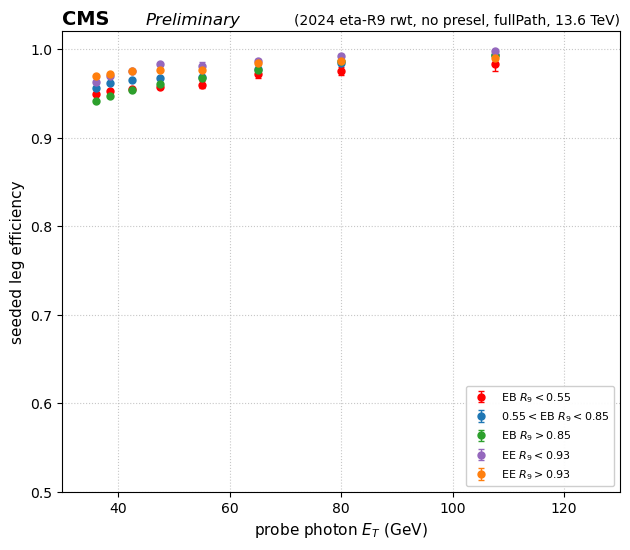

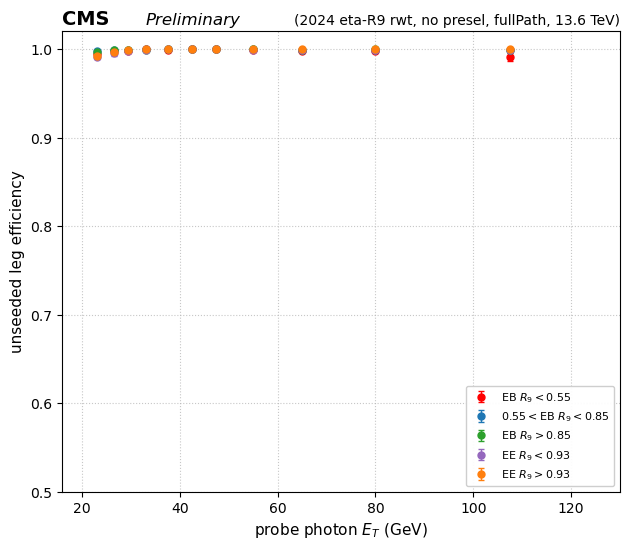

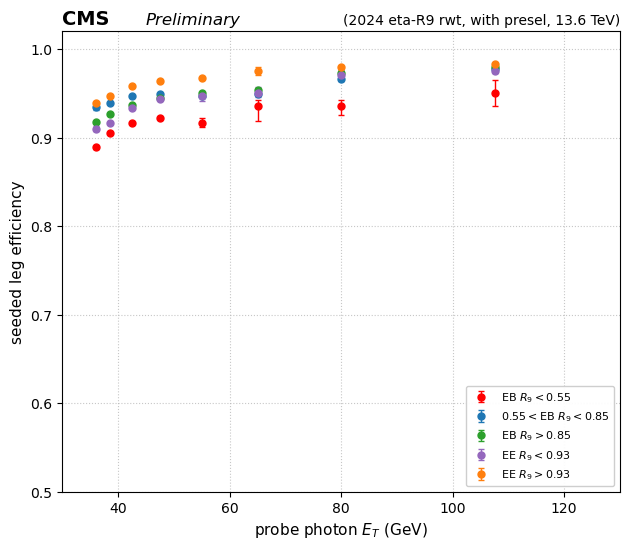

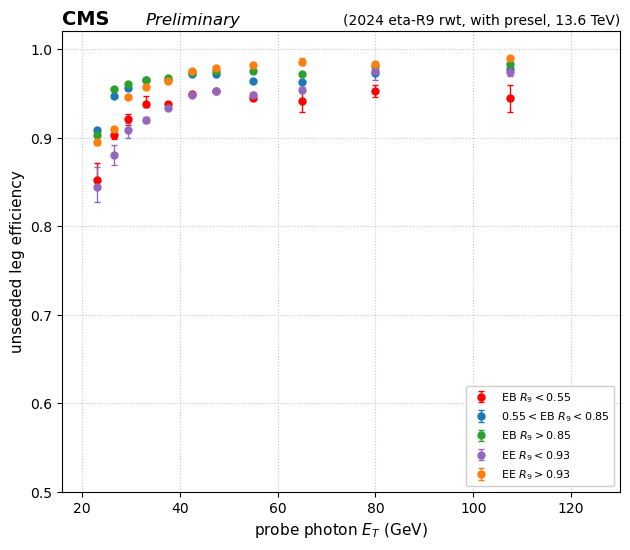

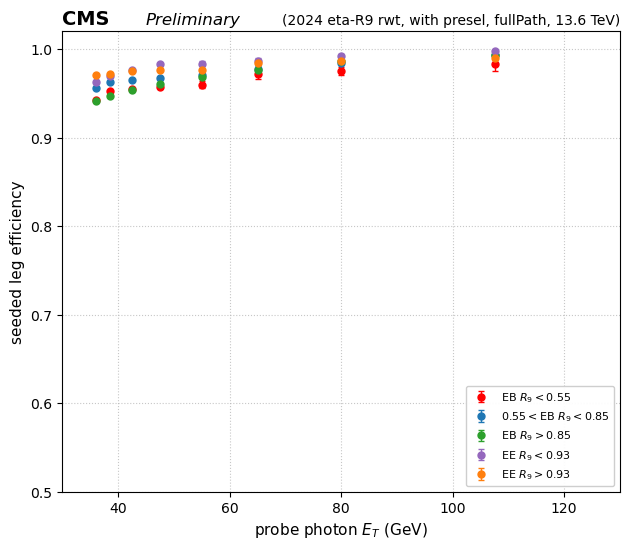

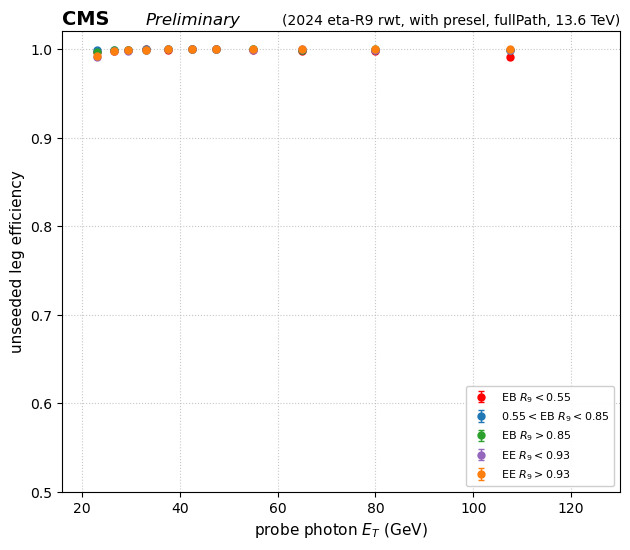

wrote:
  /home/santanu/Desktop/HLT_2024_lowmass_final/plots/efficiency-data-passing_seeded_2024_etaR9rw_noPresel.pdf
  /home/santanu/Desktop/HLT_2024_lowmass_final/plots/efficiency-data-passing_seeded_2024_etaR9rw_noPresel.png
  /home/santanu/Desktop/HLT_2024_lowmass_final/plots/efficiency-data-passing_unseeded_2024_etaR9rw_noPresel.pdf
  /home/santanu/Desktop/HLT_2024_lowmass_final/plots/efficiency-data-passing_unseeded_2024_etaR9rw_noPresel.png
  /home/santanu/Desktop/HLT_2024_lowmass_final/plots/efficiency-data-passing_seeded_2024_etaR9rw_noPresel_fullPath.pdf
  /home/santanu/Desktop/HLT_2024_lowmass_final/plots/efficiency-data-passing_seeded_2024_etaR9rw_noPresel_fullPath.png
  /home/santanu/Desktop/HLT_2024_lowmass_final/plots/efficiency-data-passing_unseeded_2024_etaR9rw_noPresel_fullPath.pdf
  /home/santanu/Desktop/HLT_2024_lowmass_final/plots/efficiency-data-passing_unseeded_2024_etaR9rw_noPresel_fullPath.png
  /home/santanu/Desktop/HLT_2024_lowmass_final/plots/efficiency-data-

In [6]:
PT_CAP = 120.0  # cap the plotted x-range; matches 2023 plotting script
MIN_PT_BY_LEG = {"seed": 35.0, "unseed": 21.0}
LEG_LABEL = {"seed": "seeded", "unseed": "unseeded"}

R9_CATS = [
    ("EB", "R9_0p50to0p55", "EB $R_9 < 0.55$",          "red"),
    ("EB", "R9_0p55to0p85", "$0.55 < $EB $R_9 < 0.85$", "tab:blue"),
    ("EB", "R9gt0p85",      "EB $R_9 > 0.85$",           "tab:green"),
    ("EE", "R9_0p90to0p93", "EE $R_9 < 0.93$",           "tab:purple"),
    ("EE", "R9gt0p93",      "EE $R_9 > 0.93$",           "tab:orange"),
]

def xmid(plo, phi):
    """Bin-center x position for the errorbar plot, with the last (overflow) bin's
    right edge capped at PT_CAP + 5 so it doesn't stretch the axis."""
    return 0.5 * (plo + min(phi, PT_CAP + 5))

nominal = df[df["variant"] == "bwDscbCms"]

def make_plot(era, leg):
    fig, ax = plt.subplots(figsize=(6.4, 5.6))
    min_pt = MIN_PT_BY_LEG[leg]
    any_data = False
    for region, r9bin, label, color in R9_CATS:
        sel = nominal[
            (nominal["era"] == era) & (nominal["leg"] == leg)
            & (nominal["region"] == region) & (nominal["R9bin"] == r9bin)
            & (nominal["et_lo"] >= min_pt)
        ].sort_values("et_lo")
        if sel.empty:
            continue
        any_data = True
        xs = [xmid(plo, phi) for plo, phi in zip(sel["et_lo"], sel["et_hi"])]
        ax.errorbar(xs, sel["eff"], yerr=[sel["err_lo"], sel["err_hi"]],
                    fmt="o", color=color, ms=5, lw=1.0, capsize=2, label=label)

    ax.set_xlim(max(15, min_pt - 5), 130)
    ax.set_ylim(0.5, 1.02)
    ax.grid(True, ls=":", alpha=0.7)
    ax.set_xlabel("probe photon $E_T$ (GeV)", fontsize=11)
    ax.set_ylabel(f"{LEG_LABEL[leg]} leg efficiency", fontsize=11)
    if any_data:
        ax.legend(loc="lower right", fontsize=8, framealpha=0.95)

    # CMS-style header; no fb^-1 number since the settings-file lumi (109.08) is flagged PLACEHOLDER
    ax.text(0.0, 1.015, "CMS", transform=ax.transAxes, fontsize=14, fontweight="bold")
    ax.text(0.15, 1.015, "Preliminary", transform=ax.transAxes, fontsize=12, fontstyle="italic")
    ax.text(1.0, 1.015, f"(2024 {ERA_DISPLAY[era]}, 13.6 TeV)",
            transform=ax.transAxes, fontsize=10, ha="right")

    fig.tight_layout()
    stem = PLOTS_DIR / f"efficiency-data-passing_{LEG_LABEL[leg]}_2024_{era}"
    fig.savefig(f"{stem}.pdf")
    fig.savefig(f"{stem}.png", dpi=150)
    plt.show()
    plt.close(fig)
    return stem

written = []
for era in sorted(nominal["era"].unique()):
    for leg in ("seed", "unseed"):
        written.append(make_plot(era, leg))

print("wrote:")
for s in written:
    print(" ", f"{s}.pdf")
    print(" ", f"{s}.png")


## 7. Completeness recap

Printed here (not just asserted in section 5) so a quick re-scroll of the executed notebook
confirms the full 5-category x 2-leg grid is present for both reweighting variants.


In [7]:
grid = (df[df["variant"] == "bwDscbCms"]
        .assign(cat=lambda d: d["region"] + "_" + d["R9bin"])
        .groupby(["era", "leg"])["cat"].nunique()
        .unstack("leg"))
print("distinct R9/eta categories per (variant, leg)  [expect 5 everywhere]:")
print(grid)


distinct R9/eta categories per (variant, leg)  [expect 5 everywhere]:
leg                          seed  unseed
era                                      
etaR9rw_noPresel                5       5
etaR9rw_noPresel_fullPath       5       5
etaR9rw_withPresel              5       5
etaR9rw_withPresel_fullPath     5       5
